# BigQuery Cost Observability

## Loading Data

In [151]:
import pandas as pd

In [152]:
import matplotlib.pyplot as plt

In [153]:
url = 'https://raw.githubusercontent.com/gitleolopes/python_projects/refs/heads/main/bigquery_cost_observability/data/bigquery_jobs_2025_mock_sample.csv'

In [154]:
bigquery_jobs = pd.read_csv(url, delimiter = ',')
bigquery_jobs.head()

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state
0,job_000001,user_011@company.com,project_36,2025-11-16 08:42:39,2025-11-16 08:42:43,2025-11-16 08:48:57,QUERY,SELECT,SELECT * FROM sales.transactions,552784715,552784715,142494,False,DONE
1,job_000002,user_032@company.com,project_36,2025-05-08 16:47:46,2025-05-08 16:47:51,2025-05-08 16:49:31,QUERY,SELECT,"SELECT id, created_at FROM users.p...",494116970,494116970,29100,False,DONE
2,job_000003,user_013@company.com,project_48,2025-01-22 18:05:14,2025-01-22 18:05:15,2025-01-22 18:12:05,QUERY,SELECT,SELECT * FROM sales.transactions,2676313420,2676313420,159490,False,DONE
3,job_000004,user_005@company.com,project_23,2025-12-18 09:57:24,2025-12-18 09:57:25,2025-12-18 10:01:49,QUERY,SELECT,SELECT * FROM events.sessions,88754095,88754095,121968,False,DONE
4,job_000005,user_073@company.com,project_41,2025-12-26 10:06:44,2025-12-26 10:06:47,2025-12-26 10:08:07,QUERY,SELECT,"SELECT id, created_at FROM users.p...",4748282422,4748282422,17680,False,DONE


## Data Profiling

In [155]:
bigquery_jobs.head()

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state
0,job_000001,user_011@company.com,project_36,2025-11-16 08:42:39,2025-11-16 08:42:43,2025-11-16 08:48:57,QUERY,SELECT,SELECT * FROM sales.transactions,552784715,552784715,142494,False,DONE
1,job_000002,user_032@company.com,project_36,2025-05-08 16:47:46,2025-05-08 16:47:51,2025-05-08 16:49:31,QUERY,SELECT,"SELECT id, created_at FROM users.p...",494116970,494116970,29100,False,DONE
2,job_000003,user_013@company.com,project_48,2025-01-22 18:05:14,2025-01-22 18:05:15,2025-01-22 18:12:05,QUERY,SELECT,SELECT * FROM sales.transactions,2676313420,2676313420,159490,False,DONE
3,job_000004,user_005@company.com,project_23,2025-12-18 09:57:24,2025-12-18 09:57:25,2025-12-18 10:01:49,QUERY,SELECT,SELECT * FROM events.sessions,88754095,88754095,121968,False,DONE
4,job_000005,user_073@company.com,project_41,2025-12-26 10:06:44,2025-12-26 10:06:47,2025-12-26 10:08:07,QUERY,SELECT,"SELECT id, created_at FROM users.p...",4748282422,4748282422,17680,False,DONE


In [156]:
bigquery_jobs.tail()

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state
79995,job_079996,user_008@company.com,project_37,2025-07-26 23:52:07,2025-07-26 23:52:09,2025-07-27 00:01:30,QUERY,SELECT,"SELECT id, created_at FROM analyti...",78107304,0,145299,True,DONE
79996,job_079997,user_081@company.com,project_41,2025-06-25 14:15:11,2025-06-25 14:15:14,2025-06-25 14:17:18,QUERY,SELECT,"SELECT id, created_at FROM sales.t...",63055802,0,7316,True,DONE
79997,job_079998,user_100@company.com,project_03,2025-12-15 02:24:40,2025-12-15 02:24:43,2025-12-15 02:33:53,QUERY,INSERT,INSERT INTO sales.transactions SELECT * FROM s...,1776942930,1776942930,149600,False,DONE
79998,job_079999,user_025@company.com,project_01,2025-06-04 15:14:40,2025-06-04 15:14:40,2025-06-04 15:17:52,QUERY,INSERT,INSERT INTO users.profile SELECT * FROM stagin...,306259168,306259168,18432,False,DONE
79999,job_080000,user_089@company.com,project_48,2025-03-10 12:03:17,2025-03-10 12:03:18,2025-03-10 12:08:55,QUERY,SELECT,"SELECT id, created_at FROM analyti...",48027637,48027637,39766,False,DONE


In [157]:
bigquery_jobs.shape

(80000, 14)

In [158]:
bigquery_jobs.columns

Index(['job_id', 'user_email', 'project_id', 'creation_time', 'start_time',
       'end_time', 'job_type', 'statement_type', 'query',
       'total_bytes_processed', 'total_bytes_billed', 'slot_ms', 'cache_hit',
       'state'],
      dtype='object')

In [159]:
bigquery_jobs.dtypes

,0
job_id,object
user_email,object
project_id,object
creation_time,object
start_time,object
end_time,object
job_type,object
statement_type,object
query,object
total_bytes_processed,int64


In [160]:
bigquery_jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   job_id                 80000 non-null  object
 1   user_email             80000 non-null  object
 2   project_id             80000 non-null  object
 3   creation_time          80000 non-null  object
 4   start_time             80000 non-null  object
 5   end_time               80000 non-null  object
 6   job_type               80000 non-null  object
 7   statement_type         80000 non-null  object
 8   query                  80000 non-null  object
 9   total_bytes_processed  80000 non-null  int64 
 10  total_bytes_billed     80000 non-null  int64 
 11  slot_ms                80000 non-null  int64 
 12  cache_hit              80000 non-null  bool  
 13  state                  80000 non-null  object
dtypes: bool(1), int64(3), object(10)
memory usage: 8.0+ MB


## Data Type Standardization

In [161]:
bigquery_jobs['creation_time'] = pd.to_datetime(bigquery_jobs['creation_time'])
bigquery_jobs['start_time'] = pd.to_datetime(bigquery_jobs['start_time'])
bigquery_jobs['end_time'] = pd.to_datetime(bigquery_jobs['end_time'])

In [162]:
bigquery_jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_id                 80000 non-null  object        
 1   user_email             80000 non-null  object        
 2   project_id             80000 non-null  object        
 3   creation_time          80000 non-null  datetime64[ns]
 4   start_time             80000 non-null  datetime64[ns]
 5   end_time               80000 non-null  datetime64[ns]
 6   job_type               80000 non-null  object        
 7   statement_type         80000 non-null  object        
 8   query                  80000 non-null  object        
 9   total_bytes_processed  80000 non-null  int64         
 10  total_bytes_billed     80000 non-null  int64         
 11  slot_ms                80000 non-null  int64         
 12  cache_hit              80000 non-null  bool          
 13  s

## Data Quality

In [163]:
bigquery_jobs.job_id.nunique()

80000

In [164]:
bigquery_jobs.job_id.duplicated().sum()

np.int64(0)

In [165]:
bigquery_jobs.isnull().sum()

,0
job_id,0
user_email,0
project_id,0
creation_time,0
start_time,0
end_time,0
job_type,0
statement_type,0
query,0
total_bytes_processed,0


In [166]:
bigquery_jobs.query('creation_time > start_time')

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state


In [167]:
bigquery_jobs.query('start_time > end_time')

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state


In [168]:
bigquery_jobs.query('total_bytes_processed <= 0')

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state


In [169]:
bigquery_jobs.query('total_bytes_billed < 0')

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state


In [170]:
bigquery_jobs.query('slot_ms <= 0')

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state


In [171]:
bigquery_jobs.query('total_bytes_billed > total_bytes_processed')

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state


In [172]:
bigquery_jobs.query('cache_hit == True and total_bytes_billed != 0')

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state


## Data Transformation

In [173]:
bigquery_jobs['creation_month'] = bigquery_jobs['creation_time'].dt.to_period('M')

In [174]:
bigquery_jobs['total_tbytes_processed'] = bigquery_jobs['total_bytes_processed']*50/(1024**4)
#Note: total_bytes_processed was scaled by a factor of 50 in the mock dataset to simulate a more representative processing volume.

In [175]:
bigquery_jobs['total_cost'] = bigquery_jobs['total_tbytes_processed']*6.25

In [176]:
bigquery_jobs['duration'] = (bigquery_jobs['end_time'] - bigquery_jobs['start_time']).dt.total_seconds()

In [177]:
bigquery_jobs.statement_type.unique()

array(['SELECT', 'UPDATE', 'INSERT', 'SCRIPT', 'DELETE'], dtype=object)

In [178]:
bigquery_jobs.statement_type.value_counts()

,count
statement_type,
SELECT,48127
INSERT,12002
SCRIPT,8017
UPDATE,7912
DELETE,3942


In [179]:
bigquery_jobs_wout_script = bigquery_jobs.query('statement_type != "SCRIPT"')

In [180]:
bigquery_jobs_wout_script.statement_type.value_counts()

,count
statement_type,
SELECT,48127
INSERT,12002
UPDATE,7912
DELETE,3942


In [181]:
bigquery_jobs_wout_script.head()

,job_id,user_email,project_id,creation_time,start_time,end_time,job_type,statement_type,query,total_bytes_processed,total_bytes_billed,slot_ms,cache_hit,state,creation_month,total_tbytes_processed,total_cost,duration
0,job_000001,user_011@company.com,project_36,2025-11-16 08:42:39,2025-11-16 08:42:43,2025-11-16 08:48:57,QUERY,SELECT,SELECT * FROM sales.transactions,552784715,552784715,142494,False,DONE,2025-11,0.025138,0.157111,374.0
1,job_000002,user_032@company.com,project_36,2025-05-08 16:47:46,2025-05-08 16:47:51,2025-05-08 16:49:31,QUERY,SELECT,"SELECT id, created_at FROM users.p...",494116970,494116970,29100,False,DONE,2025-05,0.022470,0.140436,100.0
2,job_000003,user_013@company.com,project_48,2025-01-22 18:05:14,2025-01-22 18:05:15,2025-01-22 18:12:05,QUERY,SELECT,SELECT * FROM sales.transactions,2676313420,2676313420,159490,False,DONE,2025-01,0.121705,0.760654,410.0
3,job_000004,user_005@company.com,project_23,2025-12-18 09:57:24,2025-12-18 09:57:25,2025-12-18 10:01:49,QUERY,SELECT,SELECT * FROM events.sessions,88754095,88754095,121968,False,DONE,2025-12,0.004036,0.025225,264.0
4,job_000005,user_073@company.com,project_41,2025-12-26 10:06:44,2025-12-26 10:06:47,2025-12-26 10:08:07,QUERY,SELECT,"SELECT id, created_at FROM users.p...",4748282422,4748282422,17680,False,DONE,2025-12,0.215927,1.349543,80.0


## Analysis

### Cost per Month

**Why are we analyzing this?**

This analysis can help us understand BigQuery usage over an entire year, identifying periods of high and low cost.

In [182]:
bq_month_cost = bigquery_jobs_wout_script[['creation_month', 'total_cost']]
bq_month_cost.head()

,creation_month,total_cost
0,2025-11,0.157111
1,2025-05,0.140436
2,2025-01,0.760654
3,2025-12,0.025225
4,2025-12,1.349543


In [183]:
bq_month_cost = bq_month_cost.groupby('creation_month').sum('total_cost').sort_values('creation_month').reset_index()
bq_month_cost

,creation_month,total_cost
0,2025-01,1711.162927
1,2025-02,1524.831979
2,2025-03,1789.260715
3,2025-04,1710.110243
4,2025-05,1718.743026
5,2025-06,1788.549318
6,2025-07,1708.102273
7,2025-08,1697.782894
8,2025-09,1631.549792
9,2025-10,1729.040452


<Axes: title={'center': 'Cost per Month'}, xlabel='creation_month', ylabel='Total Cost'>

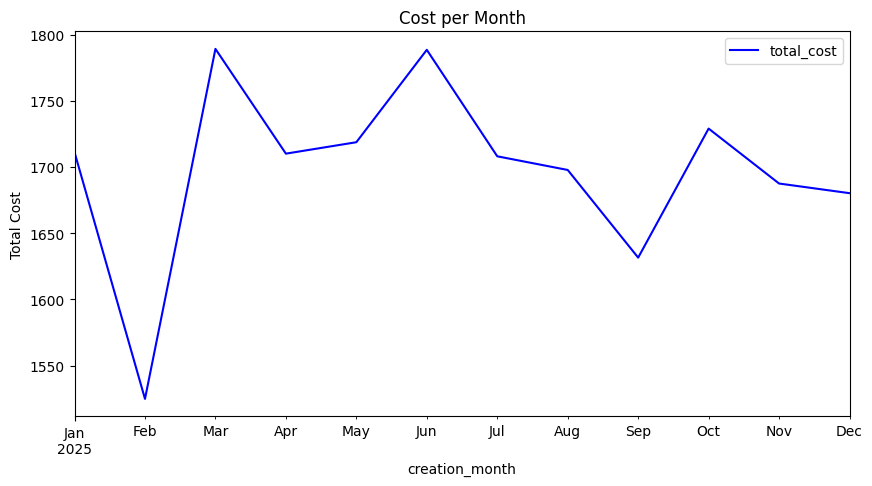

In [184]:
bq_month_cost.plot(kind = 'line'
                            ,figsize = (10, 5)
                            ,x = 'creation_month'
                            ,y = 'total_cost'
                            ,color = 'blue'
                            ,title = 'Cost per Month'
                            ,xlabel='creation_month'
                            ,ylabel = 'Total Cost')

**What did we find?**

BigQuery processing cost remained relatively stable throughout 2025, with monthly cost generally ranging between \$1524 and \$1789. February recorded the lowest processing cost at approximately \$1524, while March and June recorded the highest monthly cost at approximately \$1789.

Overall, the data does not indicate a strong upward or downward trend in processing cost throughout the year.

### Cost per Project

**Why are we analysing this?**

Identifying the projects with the highest cost can help us take action with the manager responsible for those projects.

In [185]:
bq_project_cost = bigquery_jobs_wout_script[['project_id', 'total_cost']]
bq_project_cost.head()

,project_id,total_cost
0,project_36,0.157111
1,project_36,0.140436
2,project_48,0.760654
3,project_23,0.025225
4,project_41,1.349543


In [186]:
bq_project_cost = bq_project_cost.groupby('project_id').sum('total_cost').sort_values('total_cost', ascending = True).reset_index()
bq_project_cost.head()

,project_id,total_cost
0,project_03,378.105556
1,project_20,385.515852
2,project_22,385.961894
3,project_05,386.821986
4,project_15,387.000927


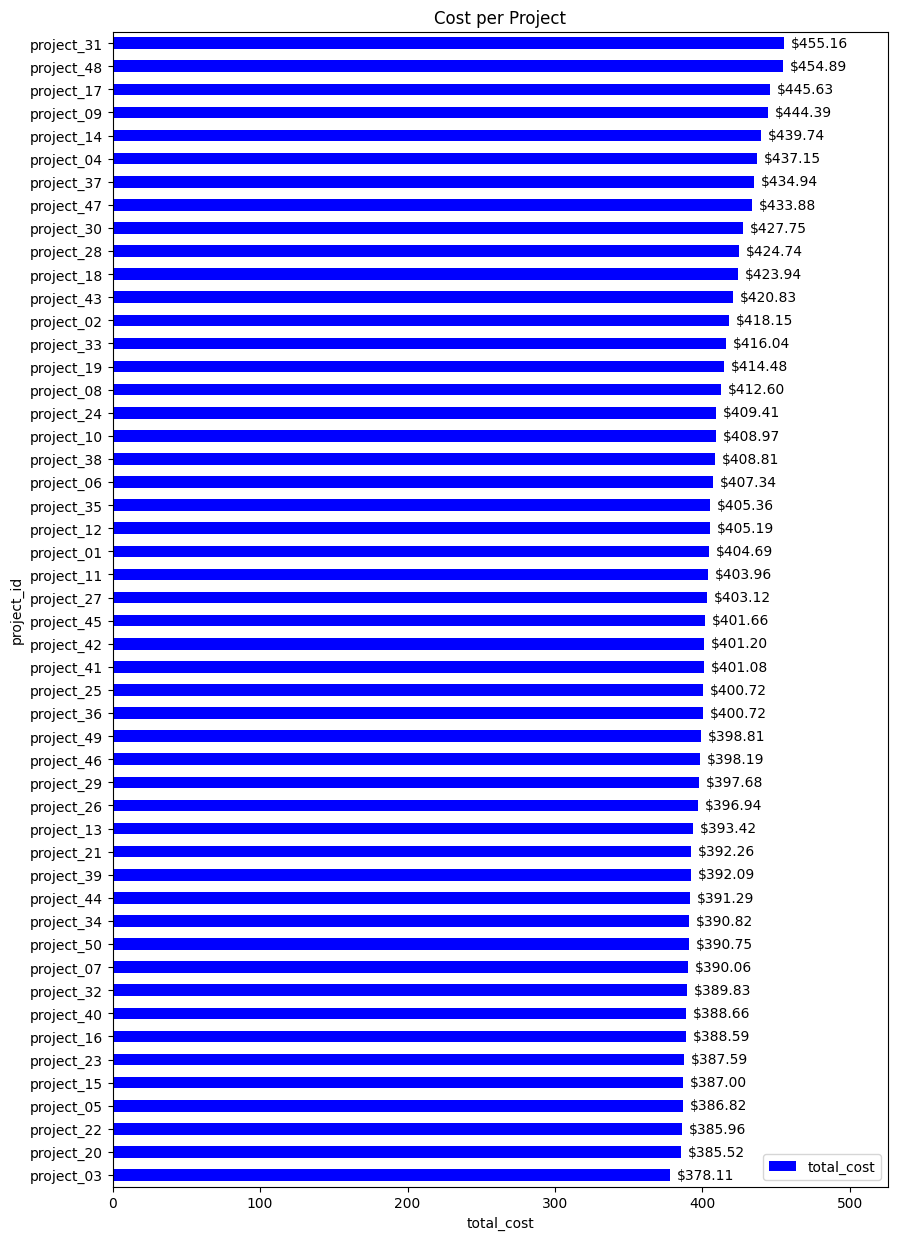

In [187]:
ax =bq_project_cost.plot(kind='barh'
                                  ,x = 'project_id'
                                  ,y='total_cost'
                                  ,figsize = (10, 15)
                                  ,color = 'blue'
                                  ,title = 'Cost per Project'
                                  ,ylabel='project_id'
                                  ,xlabel='total_cost')
ax.bar_label(ax.containers[0], fmt='$%.2f', padding=5)
ax.set_xlim(right=ax.get_xlim()[1] * 1.1)
plt.show()

In [188]:
bq_project_cost_expensive = bq_project_cost.tail(10)
bq_project_cost_expensive

,project_id,total_cost
40,project_28,424.737557
41,project_30,427.751804
42,project_47,433.884815
43,project_37,434.942605
44,project_04,437.147292
45,project_14,439.741081
46,project_09,444.385469
47,project_17,445.630570
48,project_48,454.887139
49,project_31,455.159690


<Axes: title={'center': 'Cost per Project'}, xlabel='total_cost', ylabel='project_id'>

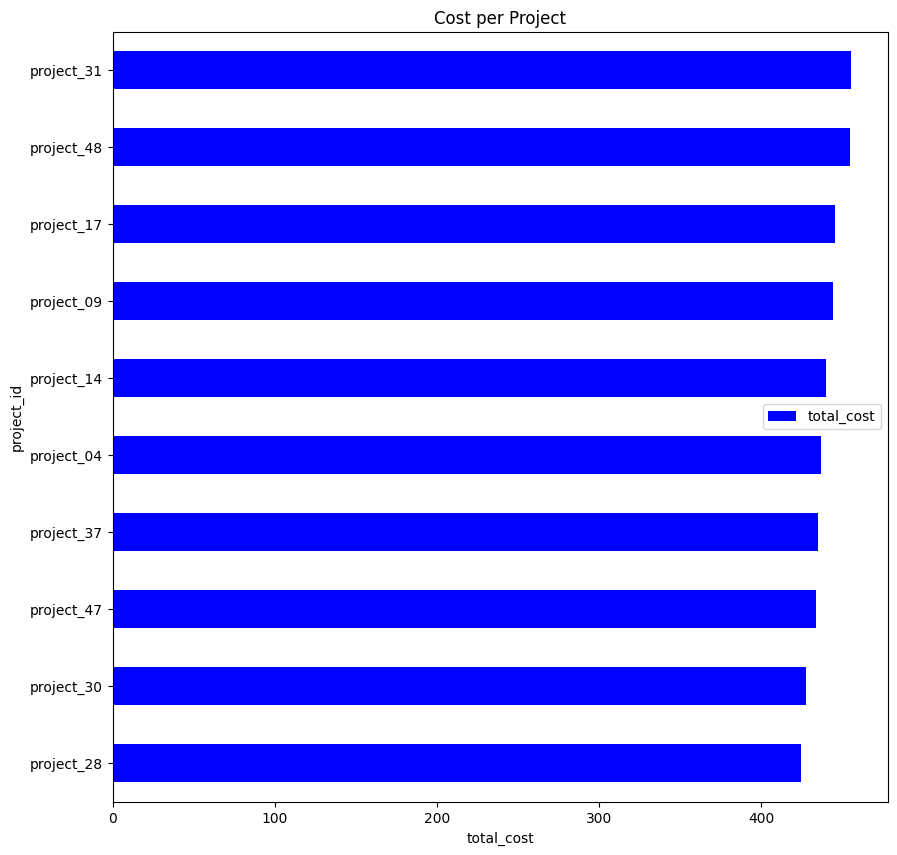

In [189]:
bq_project_cost_expensive.plot(kind = 'barh'
                          ,figsize = (10, 10)
                          ,x = 'project_id'
                          ,y = 'total_cost'
                          ,ylabel = 'project_id'
                          ,xlabel = 'total_cost'
                          ,color = 'blue'
                          ,title = 'Cost per Project')

**What did we find?**

Cost is relatively evenly distributed across projects, with no project showing a significantly higher cost than the others.

The projects with the highest costs could be prioritized for further investigation. Engaging with the managers responsible for these projects could help identify potential optimization opportunities.

### Cost per User

**Why are we analysing this?**

Identifying users with the highest processing costs can help prioritize cost optimization opportunities.

In [190]:
bq_user_cost = bigquery_jobs_wout_script[['user_email', 'total_cost']]

In [191]:
bq_user_cost = bq_user_cost.groupby('user_email').sum('total_cost').sort_values('total_cost', ascending = True).reset_index()
bq_user_cost.head()

,user_email,total_cost
0,user_076@company.com,172.386498
1,user_075@company.com,175.294088
2,user_004@company.com,177.572061
3,user_002@company.com,177.653316
4,user_068@company.com,180.623480


<Axes: title={'center': 'Cost per User'}, xlabel='total_cost', ylabel='user_email'>

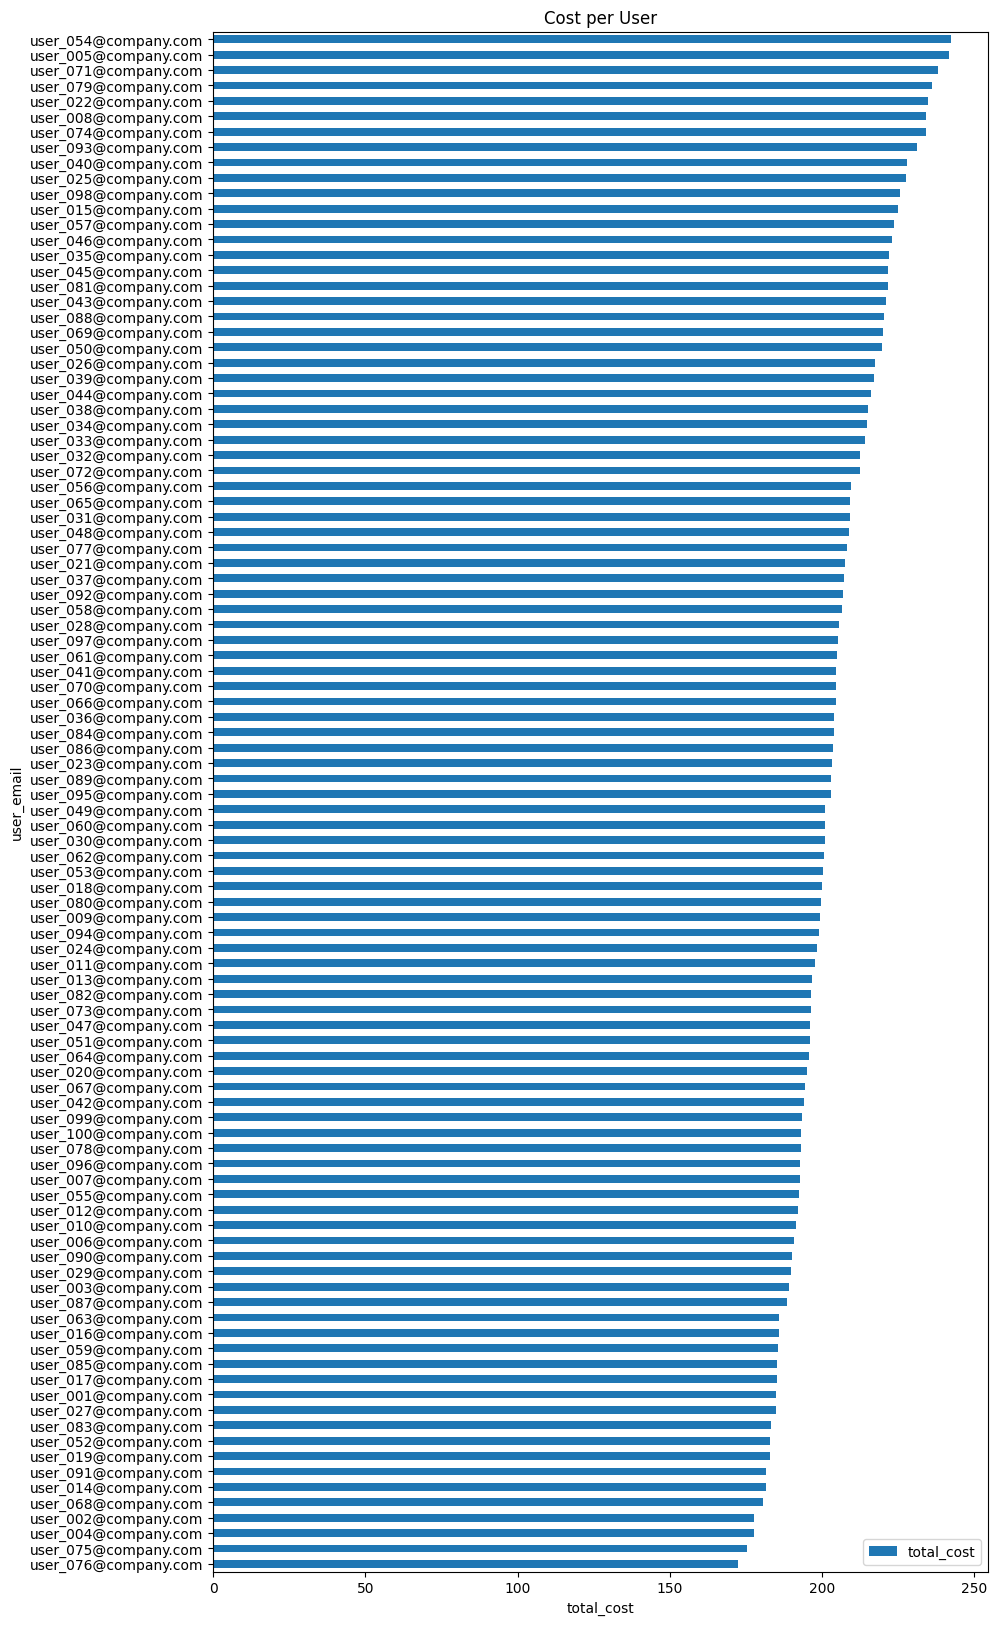

In [192]:
bq_user_cost.plot(kind = 'barh'
                              ,figsize = (10,20)
                              ,x = 'user_email'
                              ,y = 'total_cost'
                              ,title = 'Cost per User'
                              ,ylabel='user_email'
                              ,xlabel = 'total_cost')

In [193]:
bq_users_cost_expensive = bq_user_cost.tail(10)
bq_users_cost_expensive

,user_email,total_cost
90,user_025@company.com,227.471852
91,user_040@company.com,227.932905
92,user_093@company.com,231.106245
93,user_074@company.com,234.097763
94,user_008@company.com,234.184442
95,user_022@company.com,234.656234
96,user_079@company.com,236.252203
97,user_071@company.com,238.023387
98,user_005@company.com,241.557221
99,user_054@company.com,242.406934


<Axes: ylabel='user_email'>

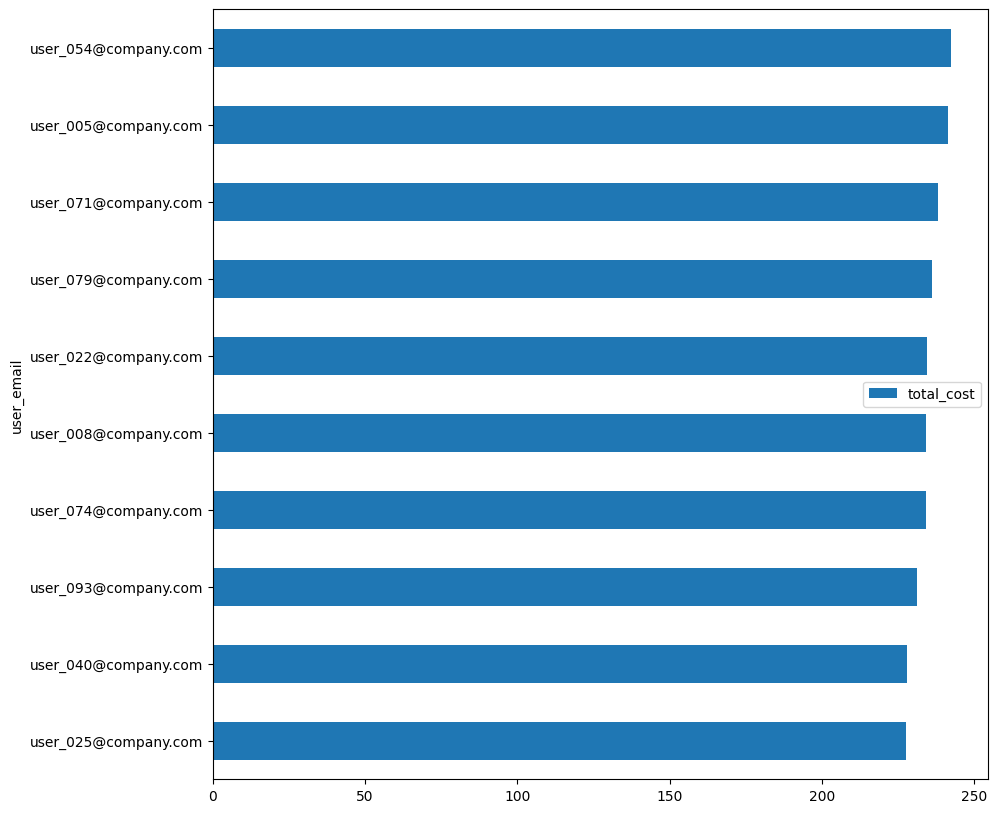

In [194]:
bq_users_cost_expensive.plot(kind = 'barh'
                                  ,figsize = (10,10)
                                  ,x = 'user_email'
                                  ,y = 'total_cost')

**What did we find?**

Cost is relatively evenly distributed across users, with no user showing a significantly higher cost than the others.

Users with higher cost could be prioritized for further analysis of query patterns and SQL practices to identify potential optimization opportunities.

### Cost vs Query Duration

**Why are we analysing this?**

Does incurring a higher estimated processing cost generally result in longer query execution times?

In [195]:
bigquery_jobs_wout_script[['total_cost', 'duration']].corr()

,total_cost,duration
total_cost,1.000000,0.003294
duration,0.003294,1.000000


In [198]:
bq_duration = bigquery_jobs_wout_script[['total_cost', 'duration']].corr()

<Axes: title={'center': 'Duration vs Cost'}, xlabel='total_cost', ylabel='duration'>

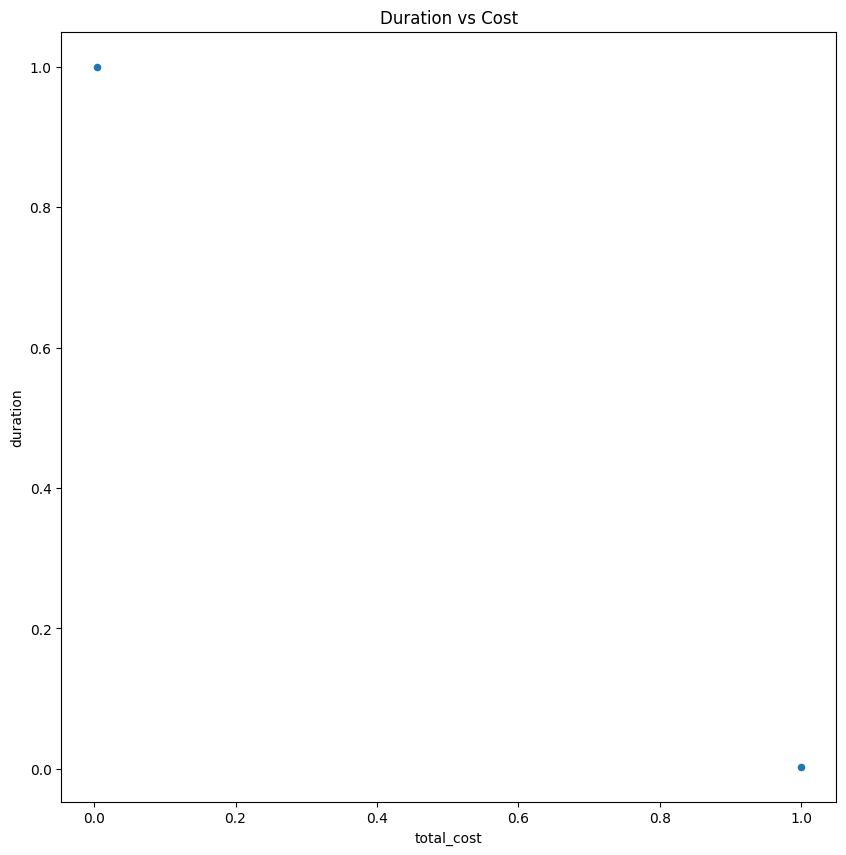

In [199]:
bq_duration.plot(kind = 'scatter'
                  ,figsize = (10,10)
                  ,x = 'total_cost'
                  ,y = 'duration'
                  ,title='Duration vs Cost')

**What did we find?**

The correlation between estimated processing cost and query duration is approximately zero (0.003294), indicating no meaningful linear relationship between cost and query execution time in this dataset.

This suggests that incurring a higher estimated processing cost does not necessarily result in longer query execution times.